参考文献 :\
佐藤竜馬: 「機械学習プロフェッショナルシリーズグラフニューラルネットワーク」 \
「SEMI-SUPERVISED CLASSIFICATION WITH GRAPH CONVOLUTIONAL NETWORKS」 \
https://arxiv.org/pdf/1609.02907 \
「PyTorch実装で理解するGraph Convolutional Network」 \
https://zenn.dev/hash_yuki/articles/cb008a7c19e917 \
「Demystifying GCNs: A Step-by-Step Guide to Building a Graph Convolutional Network Layer in PyTorch」 \
https://medium.com/@jrosseruk/demystifying-gcns-a-step-by-step-guide-to-building-a-graph-convolutional-network-layer-in-pytorch-09bf2e788a51

目的 : \
Graph Convolutional Networks の基礎理解と実装を行う。\
実装はPytorchに接続する形で行い、入力/出力はPytorch Geometric に合わせることとする。

# インポート

In [1]:
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
from typing import Any, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F

In [19]:
# ヒートマップのプロット関数
def plot_heatmap(**matrices):
    num_plots = len(matrices)
    fig, axes = plt.subplots(1, num_plots, figsize=(4*num_plots, 3))
    if num_plots == 1:
        axes = [axes]

    for i, (name, matrix) in enumerate(matrices.items()):
        axes[i].imshow(matrix, cmap='Blues', aspect='equal')
        axes[i].set_title(name)

    plt.tight_layout()
    plt.show()

# 基本的な実装

今回は、5個のノード $ V = \{v_0, v_1, v_2, v_3, v_4\} $ を持つ無向グラフを考える。\
ノード特徴量行列 $ X $ を作成する。4次元の特徴量をランダムに生成する。

(5, 4)
[[ 1.87071286  1.38795781  1.21993353  2.35168539]
 [-0.0638873   0.01857398  0.16035511  1.9296675 ]
 [ 1.59181904  0.17798227  0.50782981  0.89089751]
 [ 1.64601885  0.95905733  1.19827229  1.22349168]
 [-0.5629133   0.98446064  0.56854009  0.89851441]]


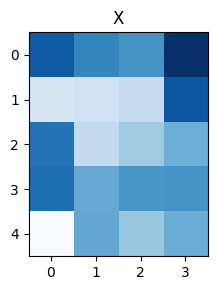

In [3]:
num_node = 5 # ノード数
in_channels = 4 # ノード特徴量の次元数
X = np.random.randn(num_node, in_channels) + 1 # ノード特徴量行列の生成（数値はランダム）

print(X.shape)
print(X)
plot_heatmap(X=X)

エッジ集合 $ E $ を作成する。 \
GCN は各頂点に自己ループを追加する。

In [4]:
E = [[0, 1], [0, 2], [1, 2], [1, 3], [1, 4], [2, 3]] # エッジの作成
reversed_E = [[j, i] for [i, j] in E] # 無向グラフなので、逆向きのエッジを作成
I = [[i, i] for i in range(num_node)] # GCNは自己ループを追加する

new_E = E + reversed_E  + I # 足し合わせる
print(new_E)

[[0, 1], [0, 2], [1, 2], [1, 3], [1, 4], [2, 3], [1, 0], [2, 0], [2, 1], [3, 1], [4, 1], [3, 2], [0, 0], [1, 1], [2, 2], [3, 3], [4, 4]]


隣接行列 $ A $ を作成する。 \
自己ループを組み込んだ隣接行列であるため、変数名は A_tilde とする。

(5, 5)
[[1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 0. 0. 1.]]


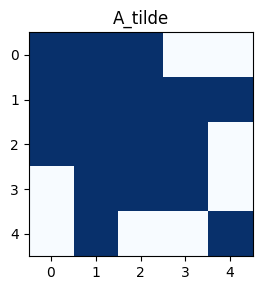

In [5]:
# エッジから隣接行列を作成する関数
def edge2mat(E, num_node):
    A = np.zeros((num_node, num_node))
    for i, j in E:
        A[i, j] = 1
    return A

A_tilde = edge2mat(new_E, num_node)

print(A_tilde.shape)
print(A_tilde)
plot_heatmap(A_tilde=A_tilde)

隣接行列 $ A $ と ノード特徴量行列 $ X $ の内積を取ることで、近傍ノードを反映した新たなノード特徴量行列が得られる。

X : 
[[ 1.87071286  1.38795781  1.21993353  2.35168539]
 [-0.0638873   0.01857398  0.16035511  1.9296675 ]
 [ 1.59181904  0.17798227  0.50782981  0.89089751]
 [ 1.64601885  0.95905733  1.19827229  1.22349168]
 [-0.5629133   0.98446064  0.56854009  0.89851441]]
new_X : 
[[ 3.3986446   1.58451406  1.88811844  5.1722504 ]
 [ 4.48175015  3.52803203  3.65493082  7.29425649]
 [ 5.04466346  2.5435714   3.08639073  6.39574209]
 [ 3.17395059  1.15561359  1.86645721  4.04405669]
 [-0.62680061  1.00303462  0.7288952   2.8281819 ]]


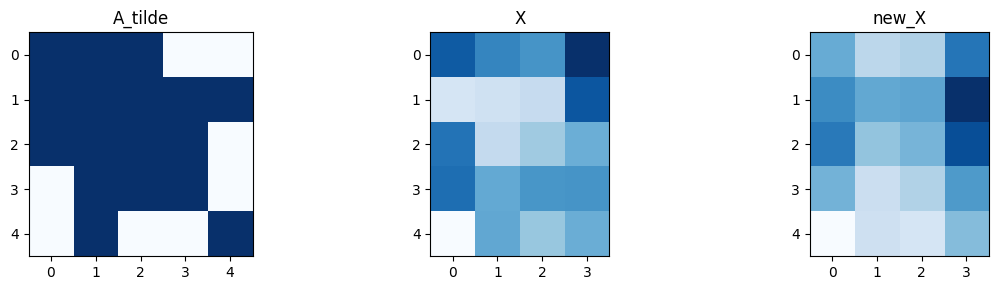

In [11]:
new_X = A_tilde @ X
print(f'X : \n{X}')
print(f'new_X : \n{new_X}')
plot_heatmap(A_tilde=A_tilde, X=X, new_X=new_X)

しかし、これでは近傍の数が多いノードほど特徴量値が爆発的に高くなってしまう。 \
今回の例では、$ v_2 $ の隣接ノードが一番多く、元の特徴量値に関係なく更新した特徴量値が大きくなっている。 \
\
そこで、近傍ノード数の平方根 $ \frac{1}{\sqrt{|\mathcal{N}(v)|}} $ で正規化を行う。 \
さらに、近傍ノードの近傍ノード数の平方根 $ \frac{1}{\sqrt{|\mathcal{N}(u) \mid  u \in \mathcal{N}(v)|}} $ を行うことで、行と列に与える影響を対象にすることができる。 \
整理すると、以下の式になる。
$$
\sum_{u \in \mathcal{N}(v)} \frac{1}{\sqrt{|\mathcal{N}(v)|} \sqrt{|\mathcal{N}(u)|}} \bm{x}_u
$$
\
これを行列計算の式に直すには、次数行列 $ D $ の逆行列の平方根 $ D^{- \frac{1}{2}} $ が必要になる。

[[0.57735027 0.         0.         0.         0.        ]
 [0.         0.4472136  0.         0.         0.        ]
 [0.         0.         0.5        0.         0.        ]
 [0.         0.         0.         0.57735027 0.        ]
 [0.         0.         0.         0.         0.70710678]]


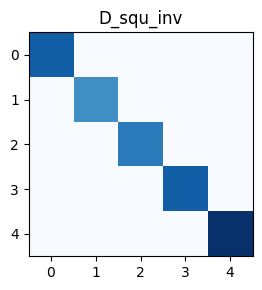

In [13]:
def get_D(A, pow=-0.5):
    D = np.zeros_like(A)
    d_ii = np.sum(A, 0)
    for i in range(len(A)):
        D[i,i] = d_ii[i] ** pow
    return D

D_squ_inv = get_D(A_tilde)
print(D_squ_inv)
plot_heatmap(D_squ_inv=D_squ_inv)

先ほどの整理した正規化の式を行列計算の形に直すと、 $ D^{- \frac{1}{2}} A D^{- \frac{1}{2}} $ となる。 \
正規化された隣接行列は $\hat A$ とする。

A_hat :
 [[0.33333333 0.25819889 0.28867513 0.         0.        ]
 [0.25819889 0.2        0.2236068  0.25819889 0.31622777]
 [0.28867513 0.2236068  0.25       0.28867513 0.        ]
 [0.         0.25819889 0.28867513 0.33333333 0.        ]
 [0.         0.31622777 0.         0.         0.5       ]]


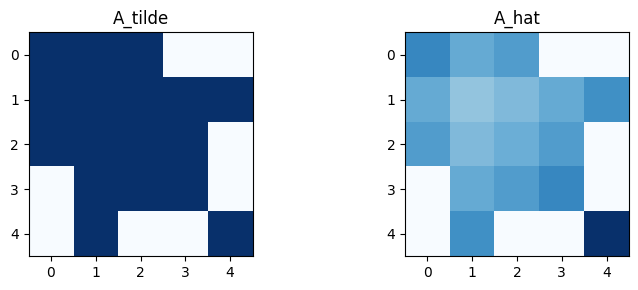

In [16]:
A_hat = D_squ_inv @ A_tilde @ D_squ_inv
print(f'A_hat :\n {A_hat}')
plot_heatmap(A_tilde=A_tilde, A_hat=A_hat)

$ \hat A $ と $X$ の内積を取ることで、近傍ノード数が大きくても新たな特徴量値が爆発せずに集約できる。

new_X :
 [[ 3.3986446   1.58451406  1.88811844  5.1722504 ]
 [ 4.48175015  3.52803203  3.65493082  7.29425649]
 [ 5.04466346  2.5435714   3.08639073  6.39574209]
 [ 3.17395059  1.15561359  1.86645721  4.04405669]
 [-0.62680061  1.00303462  0.7288952   2.8281819 ]]
norm_new_X :
 [[ 1.0665939   0.51882744  0.59464586  1.5393131 ]
 [ 1.07317151  0.96082333  0.94979144  1.79238619]
 [ 1.39886213  0.72617375  0.86088983  1.68627587]
 [ 0.9916959   0.37586062  0.58742545  1.16324853]
 [-0.30165959  0.49810393  0.33497878  1.05947165]]


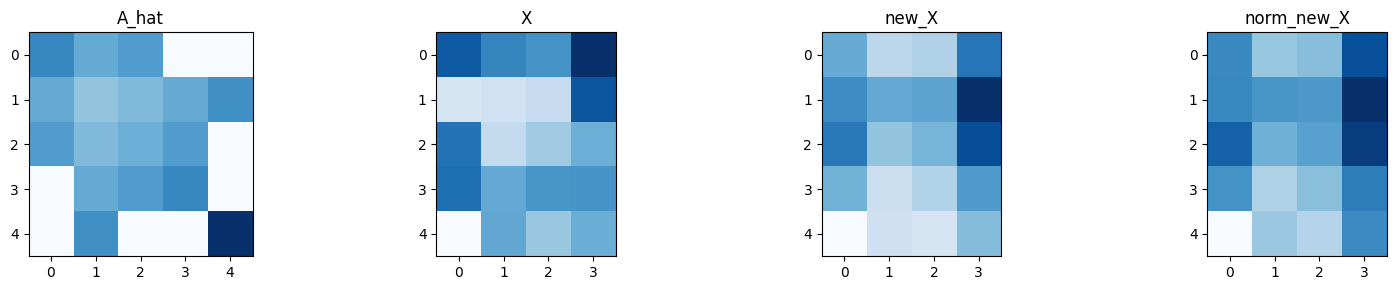

In [18]:
norm_new_X = A_hat @ X
print(f'new_X :\n {new_X}')
print(f'norm_new_X :\n {norm_new_X}')
plot_heatmap(A_hat=A_hat, X=X, new_X=new_X, norm_new_X=norm_new_X)

学習によって新たな特徴量値を得るために、パラメータ行列 $W$ を用意する。 \
ReLU関数などの非線形性を追加した数式以下になる。
$$
\sigma (\hat A X W)
$$

# レイヤークラス定義

ここからは Pytorch に実装するためのレイヤークラスの定義を行う。 \
入力や出力の形は PyG と揃える。

In [7]:
class GCNlayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        Adjacency_matrix: torch.Tensor, # 隣接行列
        ):

        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim

        # add I matrix to Adjacency_matrix
        self.A_tilde = Adjacency_matrix + torch.eye(Adjacency_matrix.size(-2)) # GCNは自己ループを必要とする。
